# Stage 1: Purchase Propensity Model

Binary classifier predicting **whether a customer will purchase in the 180-day holdout window**.

- **Target:** `purchased_in_holdout = (actual_holdout_transactions > 0)` — ~12.3% positive
- **Model:** XGBoost with `scale_pos_weight` for class imbalance + isotonic calibration
- **Primary metric:** PR-AUC (baseline = 0.123)

**Outputs:**
- `models/purchase_propensity_model.pkl`
- `data/processed/stage1_scored.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb

## 1. Load and Prepare Data

In [2]:
df = pd.read_csv("../data/raw/clv_data.csv")

# Target: binary purchase indicator
df['purchased_in_holdout'] = (df['actual_holdout_transactions'] > 0).astype(int)

positive_rate = df['purchased_in_holdout'].mean()
print(f"Loaded {len(df):,} customers")
print(f"Positive class (purchased in holdout): {df['purchased_in_holdout'].sum():,} ({positive_rate:.1%})")
print(f"Negative class (no holdout purchase):  {(df['purchased_in_holdout'] == 0).sum():,} ({1 - positive_rate:.1%})")

Loaded 52,507 customers
Positive class (purchased in holdout): 6,451 (12.3%)
Negative class (no holdout purchase):  46,056 (87.7%)


## 2. Feature Engineering

In [3]:
# Derived feature: what fraction of lifetime included repeat activity
df['recency_ratio'] = df['recency'] / df['T']

NUMERIC_FEATURES = [
    # Purchase history (BG/NBD inputs)
    'frequency', 'recency', 'T', 'monetary_value',
    # Transaction context
    'total_orders', 'avg_order_value', 'days_since_last_order',
    # Demographics
    'customer_tenure_days', 'age',
    # Engagement
    'total_sessions', 'total_events', 'days_since_last_visit',
    'avg_events_per_session', 'cart_events', 'product_view_events',
    # Derived
    'recency_ratio',
]
CATEGORICAL_FEATURES = ['gender', 'traffic_source', 'country']

# Encode categoricals
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

FEATURE_COLS = NUMERIC_FEATURES + [c + '_enc' for c in CATEGORICAL_FEATURES]

X = df[FEATURE_COLS]
y = df['purchased_in_holdout']

print(f"Features: {len(FEATURE_COLS)}")
print(f"Target distribution: {y.value_counts().to_dict()}")

Features: 19
Target distribution: {0: 46056, 1: 6451}


## 3. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} ({y_train.mean():.1%} positive)")
print(f"Test:  {len(X_test):,} ({y_test.mean():.1%} positive)")

Train: 42,005 (12.3% positive)
Test:  10,502 (12.3% positive)


## 4. Train XGBoost Classifier

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

clf = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    verbosity=0,
)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

print("XGBoost classifier trained.")

scale_pos_weight = 7.14
XGBoost classifier trained.


## 5. Probability Calibration

`scale_pos_weight` distorts raw probabilities. Isotonic regression calibrates them to match the true positive rate.

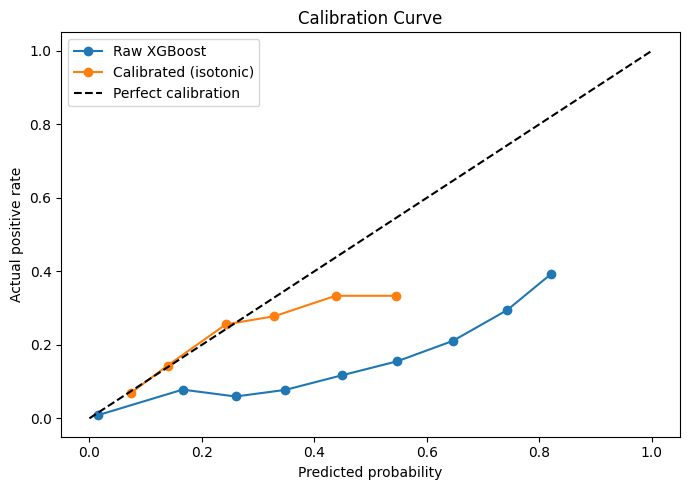

In [6]:
cal_clf = CalibratedClassifierCV(clf, method='isotonic', cv=5)
cal_clf.fit(X_train, y_train)

# Calibration curve on test set
y_prob_cal = cal_clf.predict_proba(X_test)[:, 1]
y_prob_raw = clf.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
for label, probs in [('Raw XGBoost', y_prob_raw), ('Calibrated (isotonic)', y_prob_cal)]:
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual positive rate')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluation

In [7]:
y_prob = cal_clf.predict_proba(X_test)[:, 1]

pr_auc  = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
baseline = y_test.mean()

print("=== Purchase Propensity Model ===")
print(f"PR-AUC:   {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"ROC-AUC:  {roc_auc:.4f}")

=== Purchase Propensity Model ===
PR-AUC:   0.2191  (baseline: 0.1228, lift: 1.8x)
ROC-AUC:  0.6736


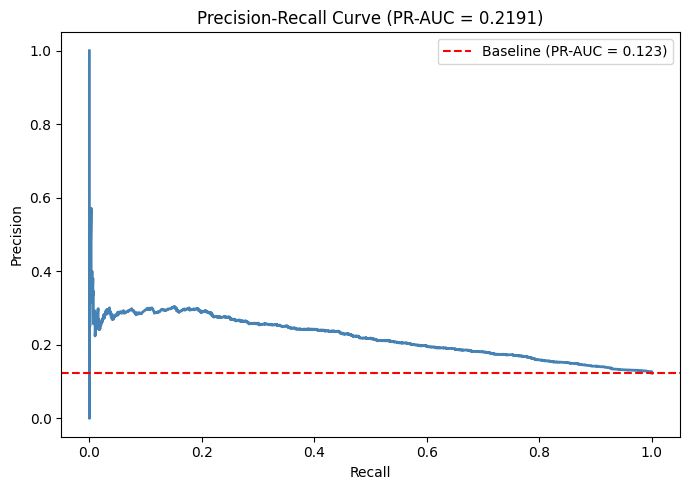

In [8]:
# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='steelblue', linewidth=2)
ax.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline (PR-AUC = {baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Decile analysis: bin customers by predicted probability, show actual purchase rate
test_df = pd.DataFrame({'y_true': y_test.values, 'y_prob': y_prob})
test_df['decile'] = pd.qcut(test_df['y_prob'], 10, labels=False, duplicates='drop') + 1

decile_stats = test_df.groupby('decile').agg(
    n_customers  = ('y_true', 'count'),
    actual_rate  = ('y_true', 'mean'),
    avg_prob     = ('y_prob', 'mean'),
).round(4)

print("=== Decile Analysis ===")
print(decile_stats.to_string())
print(f"\nTop decile purchase rate: {decile_stats.iloc[-1]['actual_rate']:.1%}")
print(f"Bottom decile purchase rate: {decile_stats.iloc[0]['actual_rate']:.1%}")
print(f"Lift (top vs bottom): {decile_stats.iloc[-1]['actual_rate'] / max(decile_stats.iloc[0]['actual_rate'], 0.001):.1f}x")

=== Decile Analysis ===
        n_customers  actual_rate  avg_prob
decile                                    
1              1061       0.0490    0.0449
2              1040       0.0587    0.0717
3              1050       0.0705    0.0772
4              1050       0.0790    0.0844
5              1051       0.0894    0.0949
6              1049       0.1153    0.1080
7              1050       0.1314    0.1266
8              1050       0.1505    0.1563
9              1050       0.2076    0.1951
10             1051       0.2769    0.2680

Top decile purchase rate: 27.7%
Bottom decile purchase rate: 4.9%
Lift (top vs bottom): 5.7x


## 7. Feature Importance

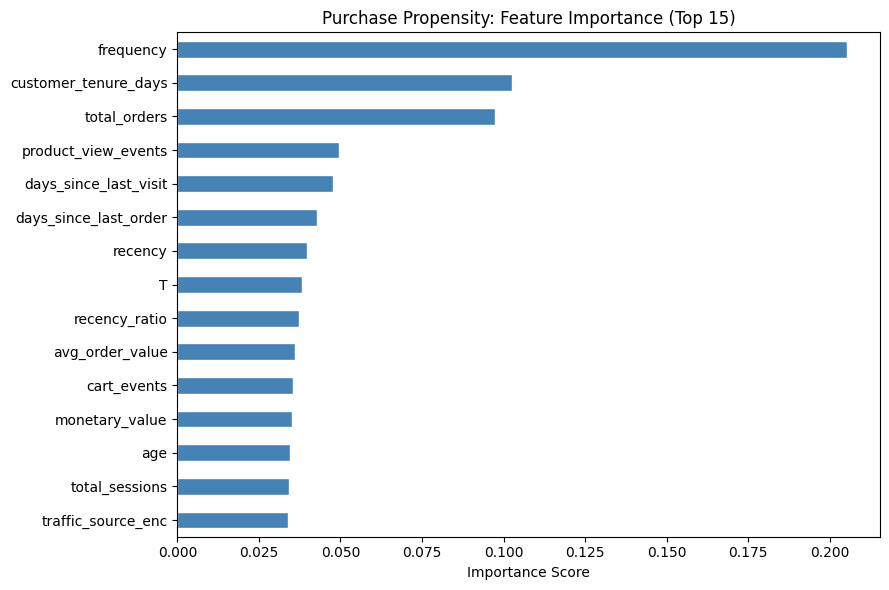

In [10]:
importance = pd.Series(clf.feature_importances_, index=FEATURE_COLS)
top_features = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top_features.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Purchase Propensity: Feature Importance (Top 15)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Score All Customers and Save

In [11]:
# Score entire dataset
df['p_purchase'] = cal_clf.predict_proba(df[FEATURE_COLS])[:, 1]

print(f"p_purchase distribution:")
print(df['p_purchase'].describe().round(4))
print(f"\nMean p_purchase: {df['p_purchase'].mean():.4f} (base rate: {df['purchased_in_holdout'].mean():.4f})")

p_purchase distribution:
count    52507.0000
mean         0.1237
std          0.0683
min          0.0000
25%          0.0771
50%          0.1015
75%          0.1560
max          0.6542
Name: p_purchase, dtype: float64

Mean p_purchase: 0.1237 (base rate: 0.1229)


In [12]:
# Save model and scored data
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

joblib.dump(cal_clf, '../models/purchase_propensity_model.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
df.to_csv('../data/processed/stage1_scored.csv', index=False)

print(f"Model saved to models/purchase_propensity_model.pkl")
print(f"Label encoders saved to models/label_encoders.pkl")
print(f"Scored data saved to data/processed/stage1_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")

Model saved to models/purchase_propensity_model.pkl
Label encoders saved to models/label_encoders.pkl
Scored data saved to data/processed/stage1_scored.csv
  Shape: 52,507 x 30


In [13]:
# Summary
print("=" * 50)
print("STAGE 1 SUMMARY: Purchase Propensity")
print("=" * 50)
print(f"Customers scored:  {len(df):,}")
print(f"PR-AUC:            {pr_auc:.4f} ({pr_auc / baseline:.1f}x lift over baseline)")
print(f"ROC-AUC:           {roc_auc:.4f}")
print(f"Mean p_purchase:   {df['p_purchase'].mean():.4f}")
print("=" * 50)
print("\nNext: 03_clv_regression.ipynb (Stage 2)")

STAGE 1 SUMMARY: Purchase Propensity
Customers scored:  52,507
PR-AUC:            0.2191 (1.8x lift over baseline)
ROC-AUC:           0.6736
Mean p_purchase:   0.1237

Next: 03_clv_regression.ipynb (Stage 2)
